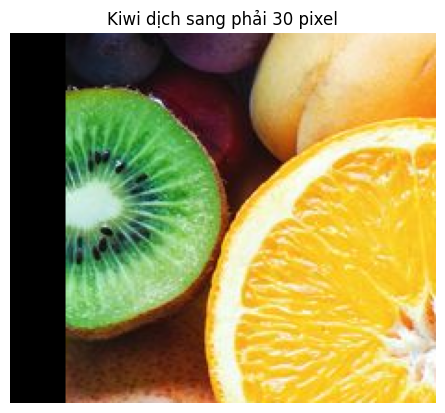

In [1]:
#bai1
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/colorful-ripe-tropical-fruits.jpg")

# Cắt vùng quả kiwi (bạn có thể chỉnh lại tọa độ)
kiwi = img[100:300, 200:400].copy()

# Ma trận tịnh tiến
M = np.float32([[1, 0, 30], [0, 1, 0]])
kiwi_shifted = cv2.warpAffine(kiwi, M, (kiwi.shape[1] + 30, kiwi.shape[0]))

# Lưu và hiển thị
cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/kiwi_translated.jpg", kiwi_shifted)

plt.imshow(cv2.cvtColor(kiwi_shifted, cv2.COLOR_BGR2RGB))
plt.title("Kiwi dịch sang phải 30 pixel")
plt.axis("off")
plt.show()


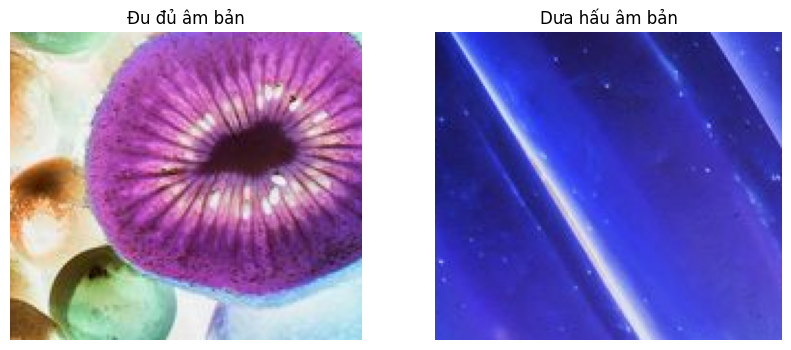

In [9]:
#bai2
img = cv2.imread(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/colorful-ripe-tropical-fruits.jpg")

# Chọn vùng quả đu đủ và dưa hấu (điều chỉnh nếu cần)
papaya = img[140:280, 100:260].copy()       # Đu đủ
watermelon = img[100:260, 550:730].copy()   # Dưa hấu

# Đổi màu sang ảnh âm bản
papaya_inv = 255 - papaya
watermelon_inv = 255 - watermelon

# Lưu và hiển thị
cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/papaya_negative.jpg", papaya_inv)
cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/watermelon_negative.jpg", watermelon_inv)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(cv2.cvtColor(papaya_inv, cv2.COLOR_BGR2RGB))
axs[0].set_title("Đu đủ âm bản")
axs[1].imshow(cv2.cvtColor(watermelon_inv, cv2.COLOR_BGR2RGB))
axs[1].set_title("Dưa hấu âm bản")
for ax in axs:
    ax.axis("off")
plt.show()


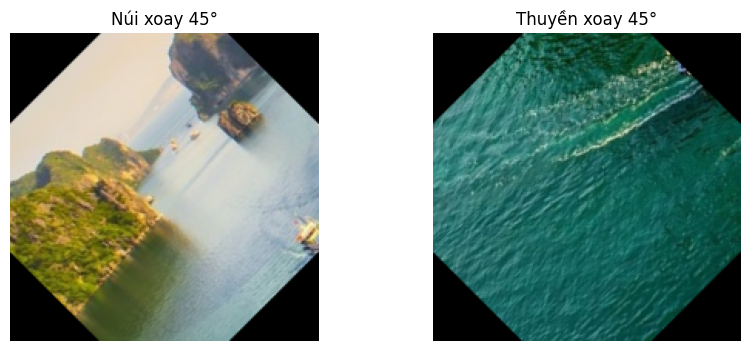

In [3]:
#bai3
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

img = cv2.imread(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/quang_ninh.jpg")

# Cắt vùng ngọn núi và thuyền (tùy bạn chỉnh lại nếu sai)
mountain = img[100:300, 100:300].copy()
boat = img[400:600, 300:500].copy()

# Xoay 45 độ
rotated1 = rotate_image(mountain, 45)
rotated2 = rotate_image(boat, 45)

cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/rotated_mountain.jpg", rotated1)
cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/rotated_boat.jpg", rotated2)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(cv2.cvtColor(rotated1, cv2.COLOR_BGR2RGB))
axs[0].set_title("Núi xoay 45°")
axs[1].imshow(cv2.cvtColor(rotated2, cv2.COLOR_BGR2RGB))
axs[1].set_title("Thuyền xoay 45°")
for ax in axs:
    ax.axis("off")
plt.show()


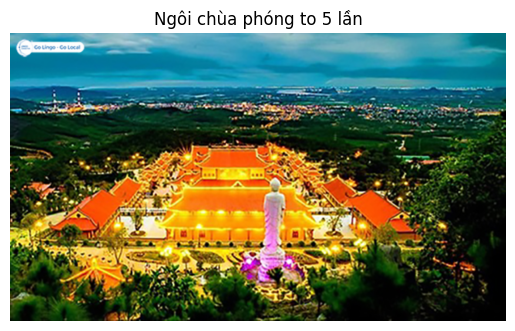

In [11]:
#bai4
img = cv2.imread(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/pagoda.jpg")

# Phóng to 5 lần
resized = cv2.resize(img, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)

cv2.imwrite(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/pagoda_zoomed.jpg", resized)

plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Ngôi chùa phóng to 5 lần")
plt.axis("off")
plt.show()


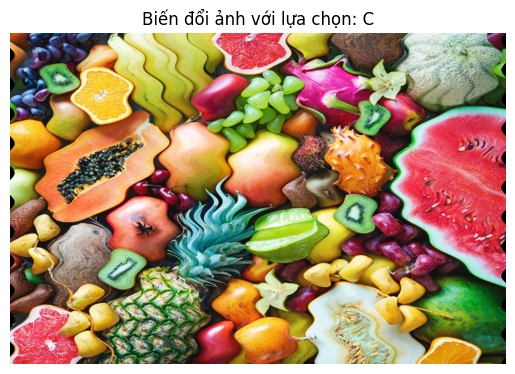

In [10]:
#bai6
def transform_image(image, option):
    if option == 'T':
        M = np.float32([[1, 0, 50], [0, 1, 30]])
        return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
    elif option == 'X':
        center = (image.shape[1] // 2, image.shape[0] // 2)
        M = cv2.getRotationMatrix2D(center, 45, 1.0)
        return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
    elif option == 'P':
        return cv2.resize(image, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
    elif option == 'H':
        return cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    elif option == 'C':
        coords = np.indices((image.shape[0], image.shape[1]), dtype=np.float32)
        coords[1] += 20.0 * np.sin(coords[0] / 20.0)
        return cv2.remap(image, coords[1], coords[0], interpolation=cv2.INTER_LINEAR)
    else:
        return image

img = cv2.imread(r"D:/nhapmonxulyanhso/nhapmonxulyanhso/XLA_lab3/exercise/colorful-ripe-tropical-fruits.jpg")

option = input("Nhập T (Tịnh tiến), X (Xoay), P (Phóng to), H (Thu nhỏ), C (Biến dạng sin): ").upper()
output = transform_image(img, option)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Biến đổi ảnh với lựa chọn: " + option)
plt.axis("off")
plt.show()
